### Import bibliotek oraz konfiguracja środowiska

In [372]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [373]:
LEAGUE = "premier_league"
# LEAGUE = "serie_a"
# LEAGUE = "la_liga"
# LEAGUE = "bundesliga"
# LEAGUE = "ligue_1"
# LEAGUE = "all_leagues"

EXPERIMENT = "data_exploration"

RAW_BASE = Path("../data/raw")

LEAGUE_DIRS = {
    "premier_league": RAW_BASE / "premier_league",
    "serie_a": RAW_BASE / "serie_a",
    "la_liga": RAW_BASE / "la_liga",
    "bundesliga": RAW_BASE / "bundesliga",
    "ligue_1": RAW_BASE / "ligue_1",
}

RESULTS_DIR = Path(f"../results/{LEAGUE}/{EXPERIMENT}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)



In [374]:
sns.set(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10,5)

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)


In [375]:
# ============================================================
# FUNKCJE ZAPISU
# ============================================================

def save_plot(name):
    plt.savefig(RESULTS_DIR / name, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

In [376]:
# ============================================================
# WCZYTANIE WIELU SEZONÓW
# ============================================================

dfs = []

if LEAGUE == "all_leagues":
    league_items = LEAGUE_DIRS.items()
else:
    league_items = [(LEAGUE, LEAGUE_DIRS[LEAGUE])]

for league_name, data_dir in league_items:
    files = sorted(data_dir.glob("*.csv"))

    for f in files:
        season = f.stem.split("_")[-2] + "/" + f.stem.split("_")[-1]
        tmp = pd.read_csv(f)
        tmp["Season"] = season
        tmp["League"] = league_name
        dfs.append(tmp)

df = pd.concat(dfs, ignore_index=True)

print("Łączny rozmiar danych:", df.shape)
display(df.head())

# ============================================================
# PARSOWANIE DAT + SORT
# ============================================================

df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=True)
df = df.sort_values("Date").reset_index(drop=True)



Łączny rozmiar danych: (3421, 132)


,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,LBH,LBD,LBA,PSH,PSD,PSA,WHH,WHD,WHA,SJH,SJD,SJA,VCH,VCD,VCA,Bb1X2,BbMxH,BbAvH,BbMxD,BbAvD,BbMxA,BbAvA,BbOU,BbMx>2.5,BbAv>2.5,BbMx<2.5,BbAv<2.5,BbAH,BbAHh,BbMxAHH,BbAvAHH,BbMxAHA,BbAvAHA,PSCH,PSCD,PSCA,Season,League,Time,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,E0,16/08/14,Arsenal,Crystal Palace,2.0,1.0,H,1.0,1.0,D,J Moss,14.0,4.0,6.0,2.0,13.0,19.0,9.0,3.0,2.0,2.0,0.0,1.0,1.25,6.5,15.0,1.25,5.50,12.00,1.30,5.0,9.0,1.25,6.00,13.00,1.26,6.45,14.01,1.25,5.5,12.0,1.25,5.75,12.00,1.25,6.25,10.50,50.0,1.30,1.25,6.70,5.96,16.00,12.43,48.0,1.77,1.72,2.26,2.10,24.0,-1.50,1.81,1.78,2.20,2.10,1.29,5.90,12.75,14/15,premier_league,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,16/08/14,Leicester,Everton,2.0,2.0,D,1.0,2.0,A,M Jones,11.0,13.0,3.0,3.0,16.0,10.0,3.0,6.0,1.0,1.0,0.0,0.0,3.20,3.4,2.4,2.90,3.20,2.40,2.90,3.3,2.3,3.25,3.40,2.25,3.14,3.38,2.46,3.10,3.1,2.4,3.00,3.30,2.38,3.20,3.40,2.40,50.0,3.30,3.06,3.45,3.32,2.42,2.36,48.0,2.10,2.00,1.90,1.80,22.0,0.25,1.88,1.85,2.10,2.02,3.11,3.40,2.47,14/15,premier_league,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,16/08/14,Man United,Swansea,1.0,2.0,A,0.0,1.0,A,M Dean,14.0,5.0,5.0,4.0,14.0,20.0,4.0,0.0,2.0,4.0,0.0,0.0,1.36,5.0,11.0,1.40,4.75,9.00,1.33,5.0,8.0,1.36,5.00,10.00,1.37,5.10,10.60,1.36,4.5,9.0,1.36,5.00,8.00,1.36,5.20,10.00,50.0,1.38,1.34,5.50,4.96,11.03,9.32,48.0,1.77,1.71,2.30,2.13,25.0,-1.50,2.18,2.08,1.87,1.79,1.45,4.81,8.25,14/15,premier_league,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,16/08/14,QPR,Hull,0.0,1.0,A,0.0,0.0,D,C Pawson,19.0,11.0,6.0,4.0,10.0,10.0,8.0,9.0,1.0,2.0,0.0,0.0,2.50,3.3,3.1,2.50,3.10,2.85,2.30,3.3,2.9,2.40,3.25,3.10,2.48,3.26,3.22,2.60,3.0,2.9,2.50,3.25,2.88,2.55,3.20,3.12,50.0,2.60,2.47,3.40,3.18,3.20,3.02,46.0,2.52,2.36,1.65,1.58,24.0,0.00,1.80,1.73,2.25,2.14,2.31,3.24,3.59,14/15,premier_league,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,16/08/14,Stoke,Aston Villa,0.0,1.0,A,0.0,0.0,D,A Taylor,12.0,7.0,2.0,2.0,14.0,9.0,2.0,8.0,0.0,3.0,0.0,0.0,1.95,3.5,4.5,1.95,3.30,3.90,2.00,3.3,3.6,1.95,3.40,4.20,1.95,3.47,4.55,1.95,3.2,4.2,1.95,3.40,4.00,1.95,3.30,4.75,50.0,2.00,1.92,3.50,3.38,4.80,4.27,44.0,2.42,2.31,1.67,1.60,23.0,-0.50,1.95,1.91,2.02,1.96,2.01,3.34,4.51,14/15,premier_league,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\tdroz\AppData\Local\Temp\ipykernel_16076\1260948427.py:31: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce", dayfirst=True)


In [377]:
# ============================================================
# PODSTAWOWA INSPEKCJA
# ============================================================



print("Liczba rekordów:", df.shape[0])
print("Liczba kolumn:", df.shape[1])
df.info()

Liczba rekordów: 3421
Liczba kolumn: 132
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421 entries, 0 to 3420
Columns: 132 entries, Div to AvgCAHA
dtypes: datetime64[ns](1), float64(122), object(9)
memory usage: 3.4+ MB


## Podstawowe informacje o zbiorze

Widać, że kolumna Date jest typu object. Należy więc przekonwertować ją na typ daty

---
title: " Opis kolumn – football-data.co.uk format"
output: html_document
---

#  Podstawowe informacje o meczu

| Kolumna | Opis |
|:--|:--|
| **Div** | Kod ligi (np. `E0` = Premier League, `E1` = Championship itd.) |
| **Date** | Data meczu |
| **HomeTeam** | Nazwa drużyny gospodarzy |
| **AwayTeam** | Nazwa drużyny gości |

---

#  Wyniki

| Kolumna | Opis |
|:--|:--|
| **FTHG** | *Full Time Home Goals* – liczba goli gospodarzy po zakończeniu meczu |
| **FTAG** | *Full Time Away Goals* – liczba goli gości po zakończeniu meczu |
| **FTR**  | *Full Time Result* – wynik meczu: `H` = gospodarze wygrali, `D` = remis, `A` = goście wygrali |
| **HTHG** | *Half Time Home Goals* – gole gospodarzy do przerwy |
| **HTAG** | *Half Time Away Goals* – gole gości do przerwy |
| **HTR**  | *Half Time Result* – wynik do przerwy (`H`, `D`, `A`) |

---

#  Informacje o meczu

| Kolumna | Opis |
|:--|:--|
| **Referee** | Nazwisko sędziego prowadzącego mecz |

---

#  Statystyki meczowe

| Kolumna | Opis |
|:--|:--|
| **HS**  | *Home Shots* – liczba strzałów gospodarzy |
| **AS**  | *Away Shots* – liczba strzałów gości |
| **HST** | *Home Shots on Target* – celne strzały gospodarzy |
| **AST** | *Away Shots on Target* – celne strzały gości |
| **HF**  | *Home Fouls* – faule gospodarzy |
| **AF**  | *Away Fouls* – faule gości |
| **HC**  | *Home Corners* – rzuty rożne gospodarzy |
| **AC**  | *Away Corners* – rzuty rożne gości |
| **HY**  | *Home Yellow Cards* – żółte kartki gospodarzy |
| **AY**  | *Away Yellow Cards* – żółte kartki gości |
| **HR**  | *Home Red Cards* – czerwone kartki gospodarzy |
| **AR**  | *Away Red Cards* – czerwone kartki gości |

---

#  Kursy bukmacherskie

##  1X2 (wynik meczu)

| Kolumna | Opis |
|:--|:--|
| **B365H**, **B365D**, **B365A** | Kursy Bet365 – Home, Draw, Away |
| **BWH**, **BWD**, **BWA** | Kursy Bet & Win |
| **IWH**, **IWD**, **IWA** | Kursy Interwetten |
| **LBH**, **LBD**, **LBA** | Kursy Ladbrokes |
| **PSH**, **PSD**, **PSA** | Kursy Pinnacle Sports (closing odds – kursy końcowe) |
| **WHH**, **WHD**, **WHA** | Kursy William Hill |
| **VCH**, **VCD**, **VCA** | Kursy VC Bet |

---

##  BetBrain – zbiorcze dane

| Kolumna | Opis |
|:--|:--|
| **Bb1X2** | Liczba bukmacherów uwzględnionych w obliczeniach |
| **BbMxH**, **BbAvH** | Maksymalny i średni kurs na gospodarzy |
| **BbMxD**, **BbAvD** | Maksymalny i średni kurs na remis |
| **BbMxA**, **BbAvA** | Maksymalny i średni kurs na gości |

---

##  Over/Under 2.5 gola

| Kolumna | Opis |
|:--|:--|
| **BbOU** | Liczba bukmacherów uwzględnionych w zakładach O/U |
| **BbMx>2.5**, **BbAv>2.5** | Maksymalny i średni kurs na **powyżej 2.5 gola** |
| **BbMx<2.5**, **BbAv<2.5** | Maksymalny i średni kurs na **poniżej 2.5 gola** |

---

## 🇨🇳 Asian Handicap

| Kolumna | Opis |
|:--|:--|
| **BbAH** | Liczba bukmacherów oferujących AH |
| **BbAHh** | Linia handicapu (np. `-0.5`, `+1.0` itd.) |
| **BbMxAHH**, **BbAvAHH** | Maksymalny i średni kurs na gospodarzy przy danym AH |
| **BbMxAHA**, **BbAvAHA** | Maksymalny i średni kurs na gości przy danym AH |

---

##  Closing Odds Pinnacle

| Kolumna | Opis |
|:--|:--|
| **PSCH**, **PSCD**, **PSCA** | Końcowe kursy (*closing odds*) z Pinnacle – Home / Draw / Away |


## Wstępne czyszczenie strukturalne

In [378]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
display(missing)
print("Liczba duplikatów:", df.duplicated().sum())
df = df.sort_values('Date').reset_index(drop=True)


SJH      3381
SJD      3381
SJA      3381
IWCD     2086
IWCA     2086
         ... 
B365D       1
B365H       1
AR          1
HR          1
PSCH        1
Length: 130, dtype: int64

Liczba duplikatów: 0


## Wybór kolumn istotnych do analizy

In [379]:
# ============================================================
# WYBÓR KOLUMN (CORE — JAK W ORYGINALE)
# ============================================================

core_columns = [
    'Div', 'Date', 'Season', 'HomeTeam', 'AwayTeam',
    'FTHG', 'FTAG', 'FTR',
    'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC',
    'HY', 'AY', 'HR', 'AR',
    'B365H', 'B365D', 'B365A',
    'PSH', 'PSD', 'PSA',
    'BbMxH', 'BbMxD', 'BbMxA',
    'BbAvH', 'BbAvD', 'BbAvA',
    'Bb1X2'
]

df = df[core_columns]

Pozbywamy się nadmiarowych danych dotyczących bukmacherów


In [380]:
df.describe().T




,count,mean,min,25%,50%,75%,max,std
Date,3420,2019-06-17 16:57:15.789473792,2014-08-16 00:00:00,2016-10-29 00:00:00,2018-12-28 00:00:00,2022-03-18 06:00:00,2024-05-19 00:00:00,NaN
FTHG,3420.0,1.551,0.0,1.0,1.0,2.0,9.0,1.328
FTAG,3420.0,1.25,0.0,0.0,1.0,2.0,8.0,1.203
HS,3420.0,14.08,0.0,10.0,14.0,18.0,43.0,5.762
AS,3420.0,11.415,0.0,8.0,11.0,14.0,31.0,4.934
HST,3420.0,4.794,0.0,3.0,4.0,6.0,17.0,2.663
AST,3420.0,3.963,0.0,2.0,4.0,5.0,15.0,2.323
HF,3420.0,10.595,0.0,8.0,11.0,13.0,24.0,3.411
AF,3420.0,10.927,1.0,8.0,11.0,13.0,26.0,3.556
HC,3420.0,5.781,0.0,4.0,5.0,8.0,19.0,3.104


## Rozkład wyników

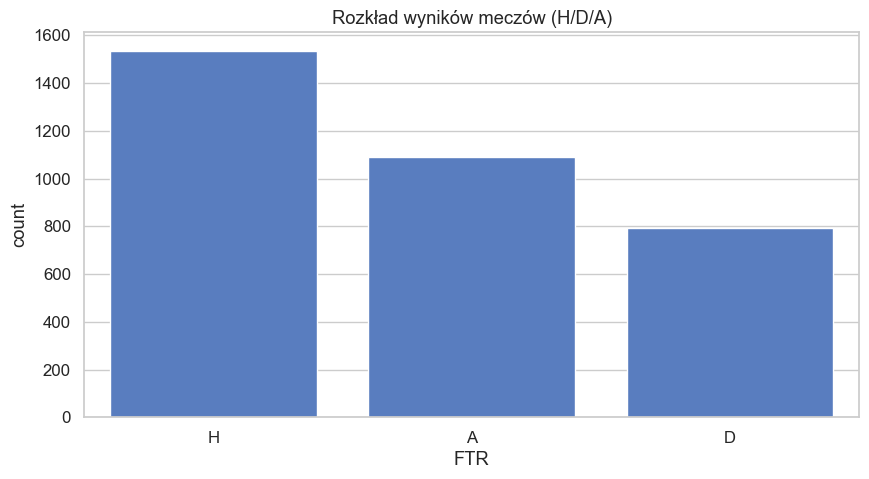

FTR
H    44.912
A    31.871
D    23.216
Name: proportion, dtype: float64


In [381]:
# ============================================================
# ROZKŁAD WYNIKÓW
# ============================================================

sns.countplot(x="FTR", data=df, order=df["FTR"].value_counts().index)
plt.title("Rozkład wyników meczów (H/D/A)")
save_plot("ftr_distribution.png")

print(df["FTR"].value_counts(normalize=True) * 100)

## Wniosek:
Gospodarze wygrywają w około 44% przypadków, co pokrywa się z ogólnymi statystykami, gdzie ten procent balansuje między 40-50.


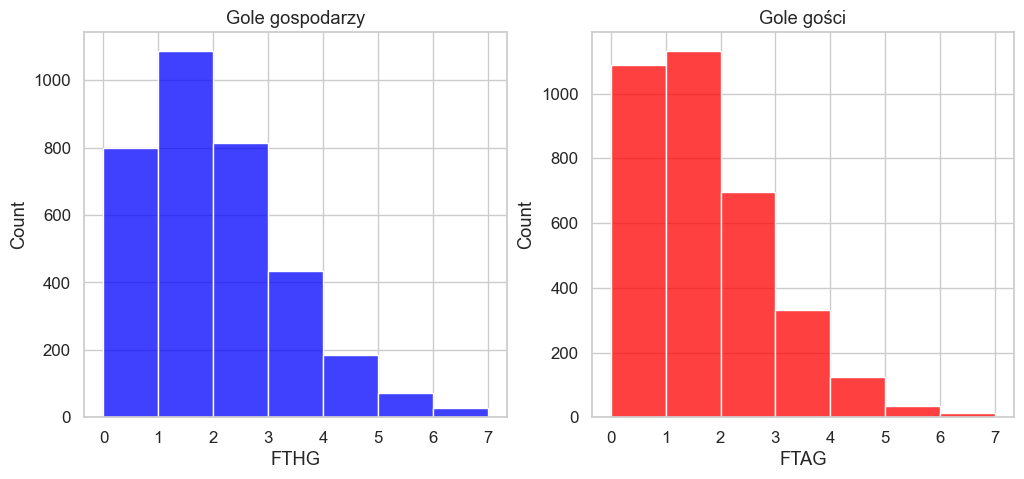

Średnia goli gospodarzy: 1.55
Średnia goli gości: 1.25
Średnia łączna liczba goli: 2.8


In [382]:
# ============================================================
# GOLE
# ============================================================
df["TotalGoals"] = df["FTHG"] + df["FTAG"]
fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(df['FTHG'], bins=range(0,8), ax=ax[0], color='blue')
sns.histplot(df['FTAG'], bins=range(0,8), ax=ax[1], color='red')
ax[0].set_title("Gole gospodarzy")
ax[1].set_title("Gole gości")
save_plot("goals_home_away_hist.png")
plt.show()

print("Średnia goli gospodarzy:", round(df['FTHG'].mean(), 2))
print("Średnia goli gości:", round(df['FTAG'].mean(), 2))
print("Średnia łączna liczba goli:", round(df['TotalGoals'].mean(), 2))

# średnia liczba strzelonych goli

Widać, że gospoddarze średnio strzelają nieco więcej bramek - widoczny jest efekt przewagi w rozgrywaniu meczów u siebie

 Statystyki meczu a wynik (gospodarze):


,Strzały gospodarzy,Celne strzały gospodarzy,Rzuty rożne gospodarzy,Żółte kartki gospodarzy,Czerwone kartki gospodarzy
FTR,,,,,
A,12.07,3.43,5.46,1.69,0.10
D,14.03,4.34,5.95,1.76,0.05
H,15.53,5.99,5.92,1.47,0.03


 Statystyki meczu a wynik (goście):


,Strzały gości,Celne strzały gości,Rzuty rożne gości,Żółte kartki gości,Czerwone kartki gości
FTR,,,,,
A,13.30,5.34,4.91,1.70,0.04
D,11.51,3.80,4.65,1.91,0.07
H,10.03,3.07,4.51,1.79,0.09


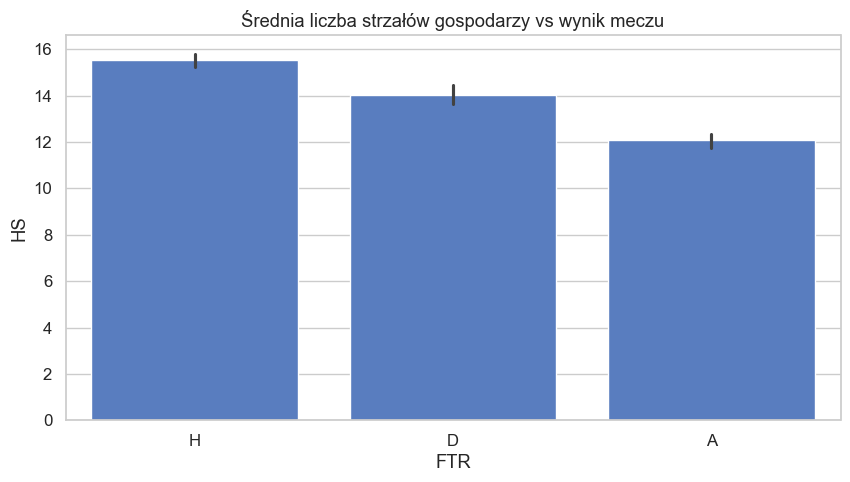

In [383]:
# --- Statystyki gospodarzy ---
home_stats = (
    df.groupby('FTR')[['HS', 'HST', 'HC', 'HY', 'HR']]
    .mean()
    .round(2)
    .rename(columns={
        'HS': 'Strzały gospodarzy',
        'HST': 'Celne strzały gospodarzy',
        'HC': 'Rzuty rożne gospodarzy',
        'HY': 'Żółte kartki gospodarzy',
        'HR': 'Czerwone kartki gospodarzy'
    })
)

print(" Statystyki meczu a wynik (gospodarze):")
display(home_stats)


# --- Statystyki gości ---
away_stats = (
    df.groupby('FTR')[['AS', 'AST', 'AC', 'AY', 'AR']]
    .mean()
    .round(2)
    .rename(columns={
        'AS': 'Strzały gości',
        'AST': 'Celne strzały gości',
        'AC': 'Rzuty rożne gości',
        'AY': 'Żółte kartki gości',
        'AR': 'Czerwone kartki gości'
    })
)

print(" Statystyki meczu a wynik (goście):")
display(away_stats)

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='FTR', y='HS', data=df)
plt.title('Średnia liczba strzałów gospodarzy vs wynik meczu')
save_plot("shots_vs_result.png")
plt.show()


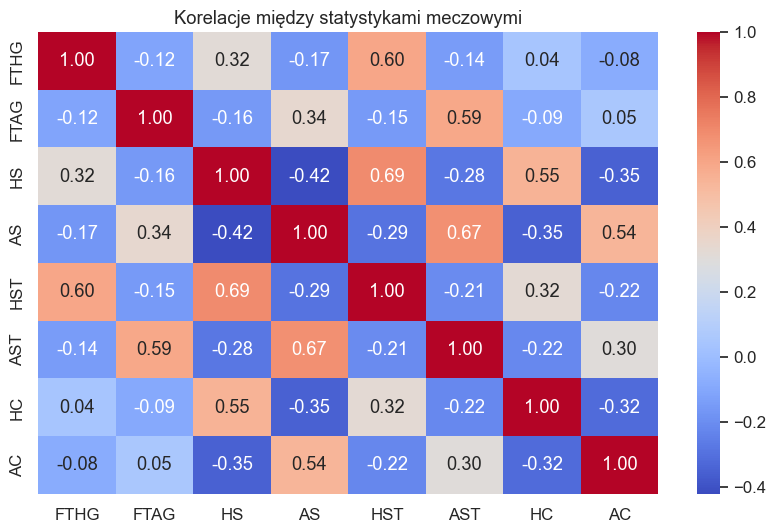

In [384]:
corr = df[['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC']].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelacje między statystykami meczowymi")
save_plot("correlations_basic.png")
plt.show()


## Wnioski z macierzy korelacji między statystykami meczowymi:

Wysoka dodatnia korelacja między HS (strzały gospodarzy) a HST (celne strzały gospodarzy) – ok. 0.69.
- Oznacza to, że drużyny oddające więcej strzałów ogółem bardzo często generują również większą liczbę strzałów celnych.
Podobnie u gości: AS i AST mają korelację ok. 0.67, co wskazuje na analogiczną zależność po stronie drużyn przyjezdnych.

HST (celne strzały gospodarzy) ma silną dodatnią korelację z FTHG (gole gospodarzy) na poziomie ok. 0.60,
- co jest w pełni logiczne – większa liczba celnych strzałów wyraźnie zwiększa szansę na zdobycie bramki przez gospodarzy.

AST (celne strzały gości) koreluje z FTAG (gole gości) na poziomie ok. 0.59,
- czyli obserwujemy bardzo podobny mechanizm po stronie zespołów wyjazdowych – skuteczność strzałów ma kluczowe znaczenie dla liczby zdobytych goli.

Liczba rzutów rożnych wykazuje umiarkowaną korelację z aktywnością ofensywną:

HC z HS ≈ 0.55

AC z AS ≈ 0.54

- sugeruje to, że drużyny częściej atakujące i oddające więcej strzałów częściej wywalczają rzuty rożne, choć nie jest to bezpośredni wskaźnik skuteczności strzeleckiej.

Korelacje między statystykami gospodarzy i gości są w większości niskie lub ujemne, np.:

HS vs AS ≈ -0.42

HC vs AC ≈ -0.32

- oznacza to, że dominacja jednej drużyny w ofensywie często odbywa się kosztem aktywności ofensywnej przeciwnika, co dobrze oddaje rywalizacyjny charakter meczu.

Brak istotnej korelacji między FTHG a FTAG (≈ -0.12),
- wskazuje na względną niezależność liczby goli zdobywanych przez gospodarzy i gości — wysoki wynik jednej drużyny nie implikuje automatycznie wysokiej liczby bramek drugiej strony.

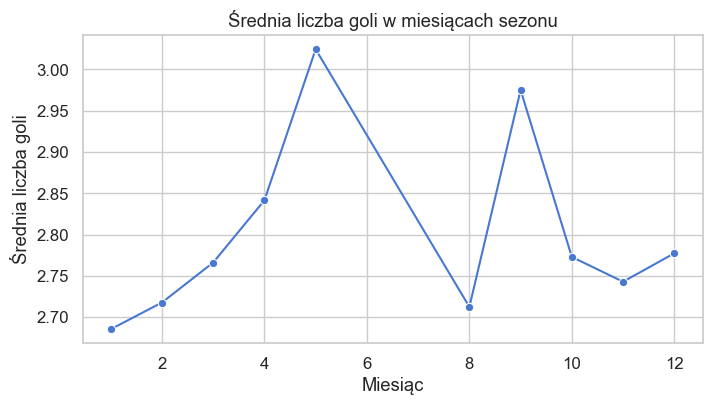

In [385]:
df['Month'] = df['Date'].dt.month
monthly_goals = df.groupby('Month')['TotalGoals'].mean()

plt.figure(figsize=(8,4))
sns.lineplot(x=monthly_goals.index, y=monthly_goals.values, marker='o')
plt.title("Średnia liczba goli w miesiącach sezonu")
plt.xlabel("Miesiąc")
plt.ylabel("Średnia liczba goli")
save_plot("monthly_goals.png")
plt.show()


## Wnioski:
Analiza średniej liczby zdobywanych bramek w poszczególnych miesiącach sezonu ujawnia wyraźne zróżnicowanie w czasie.
Wartości najwyższe obserwowane są w maju (ponad 3 gole na mecz), natomiast najniższe w grudniu i sierpniu.
Można zauważyć, że końcowa faza sezonu sprzyja bardziej ofensywnej grze, podczas gdy w jego początkowych i zimowych miesiącach liczba bramek ulega ograniczeniu.
Może to wynikać z czynników zewnętrznych, takich jak warunki pogodowe, obciążenie meczowe czy motywacja zespołów.

## Porównanie statystyk gospodarze vs goście

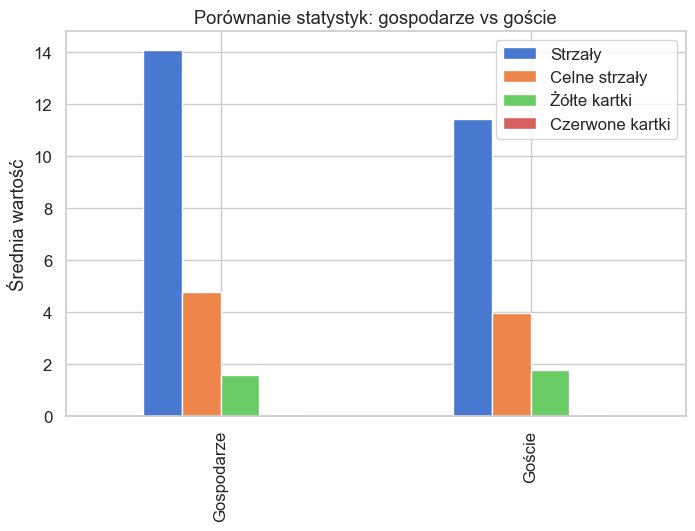

In [386]:
team_comparison = pd.DataFrame({
    'Strzały': [df['HS'].mean(), df['AS'].mean()],
    'Celne strzały': [df['HST'].mean(), df['AST'].mean()],
    'Żółte kartki': [df['HY'].mean(), df['AY'].mean()],
    'Czerwone kartki': [df['HR'].mean(), df['AR'].mean()]
}, index=['Gospodarze', 'Goście'])

team_comparison.plot(kind='bar', figsize=(8,5))
plt.title("Porównanie statystyk: gospodarze vs goście")
plt.ylabel("Średnia wartość")
save_plot("home_vs_away.png")
plt.show()


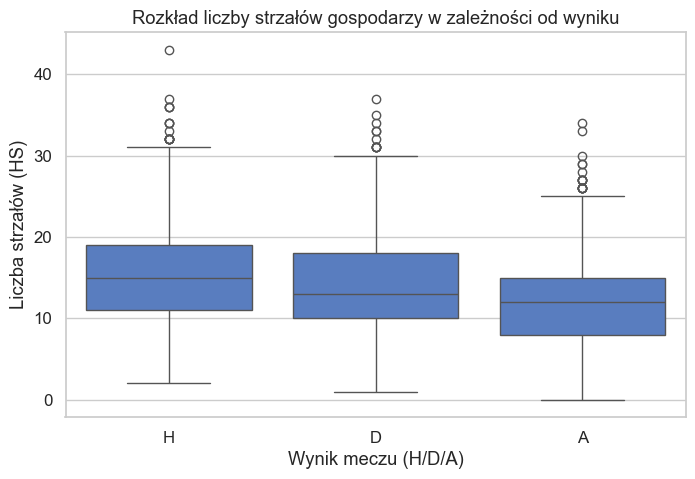

In [387]:
plt.figure(figsize=(8,5))
sns.boxplot(x='FTR', y='HS', data=df)
plt.title("Rozkład liczby strzałów gospodarzy w zależności od wyniku")
plt.xlabel("Wynik meczu (H/D/A)")
plt.ylabel("Liczba strzałów (HS)")
save_plot("boxplot_shots_vs_result.png")
plt.show()


## Wnioski:
Na wykresie pudełkowym przedstawiono zależność pomiędzy liczbą oddanych strzałów przez drużynę gospodarzy (HS) a wynikiem meczu (FTR).
Zauważalna jest tendencja, że wygrane spotkania (H) wiążą się z większą liczbą strzałów w porównaniu do remisów (D) i porażek (A).
W przypadku remisów obserwuje się szeroki rozrzut wartości, co może świadczyć o dużej zmienności w skuteczności zespołów.
Wyniki te potwierdzają, że liczba oddanych strzałów jest jedną z kluczowych zmiennych wpływających na końcowy rezultat meczu.

## ROZKŁAD WYNIKÓW (H/D/A) PER SEZON

In [388]:
# ============================================
# Rozkład wyników per sezon — tabela
# ============================================

season_ftr_dist = (
    df
    .groupby("Season")["FTR"]
    .value_counts(normalize=True)
    .rename("Percentage")
    .mul(100)
    .reset_index()
)

display(season_ftr_dist)

# zapis do CSV
season_ftr_dist.to_csv(
    RESULTS_DIR / "ftr_distribution_per_season.csv",
    index=False
)


,Season,FTR,Percentage
0,14/15,H,45.263
1,14/15,A,30.263
2,14/15,D,24.474
3,15/16,H,41.316
4,15/16,A,30.526
5,15/16,D,28.158
6,16/17,H,49.211
7,16/17,A,28.684
8,16/17,D,22.105
9,17/18,H,45.526


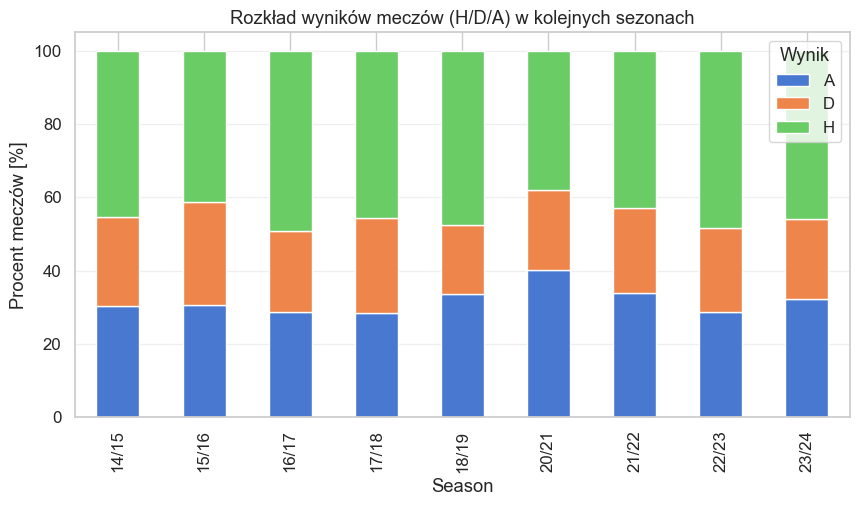

In [389]:
# ============================================
# Rozkład wyników per sezon — wykres
# ============================================

season_ftr_pivot = (
    season_ftr_dist
    .pivot(index="Season", columns="FTR", values="Percentage")
    .fillna(0)
    .sort_index()
)

season_ftr_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10,5)
)

plt.ylabel("Procent meczów [%]")
plt.title("Rozkład wyników meczów (H/D/A) w kolejnych sezonach")
plt.legend(title="Wynik")
plt.grid(axis="y", alpha=0.3)

save_plot("ftr_distribution_per_season.png")


## Wnioski z rozkładu wyników meczów (H/D/A) w kolejnych sezonach Premier League

Zwycięstwa gospodarzy (H) dominują w każdym sezonie i zwykle stanowią ok. 42–49% wszystkich meczów, co potwierdza istnienie wyraźnej przewagi własnego boiska w Premier League.

Sezon 2020/21 wyraźnie odstaje od pozostałych — odsetek zwycięstw gospodarzy spadł do 37.9%, a wygrane gości wzrosły aż do 40.3%, co można wiązać z grą bez kibiców podczas pandemii COVID-19.

Remisy (D) utrzymują się na stosunkowo stabilnym poziomie ok. 20–28%, z najniższą wartością w sezonie 2018/19 (18.7%), co sugeruje większą liczbę rozstrzygniętych spotkań w tym okresie.

W ostatnich sezonach (2021/22–2023/24) struktura wyników wraca do typowego układu, z ponownym wzrostem udziału zwycięstw gospodarzy i spadkiem wygranych drużyn wyjazdowych.

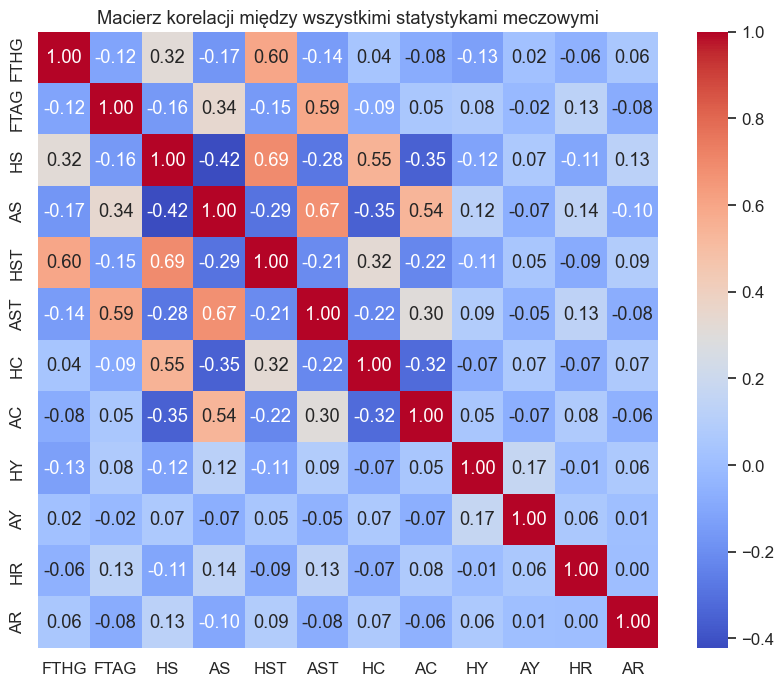

In [390]:
corr_features = [
    'FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST',
    'HC', 'AC', 'HY', 'AY', 'HR', 'AR'
]

plt.figure(figsize=(10,8))
sns.heatmap(df[corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz korelacji między wszystkimi statystykami meczowymi")
save_plot("matrix_all_features.png")
plt.show()


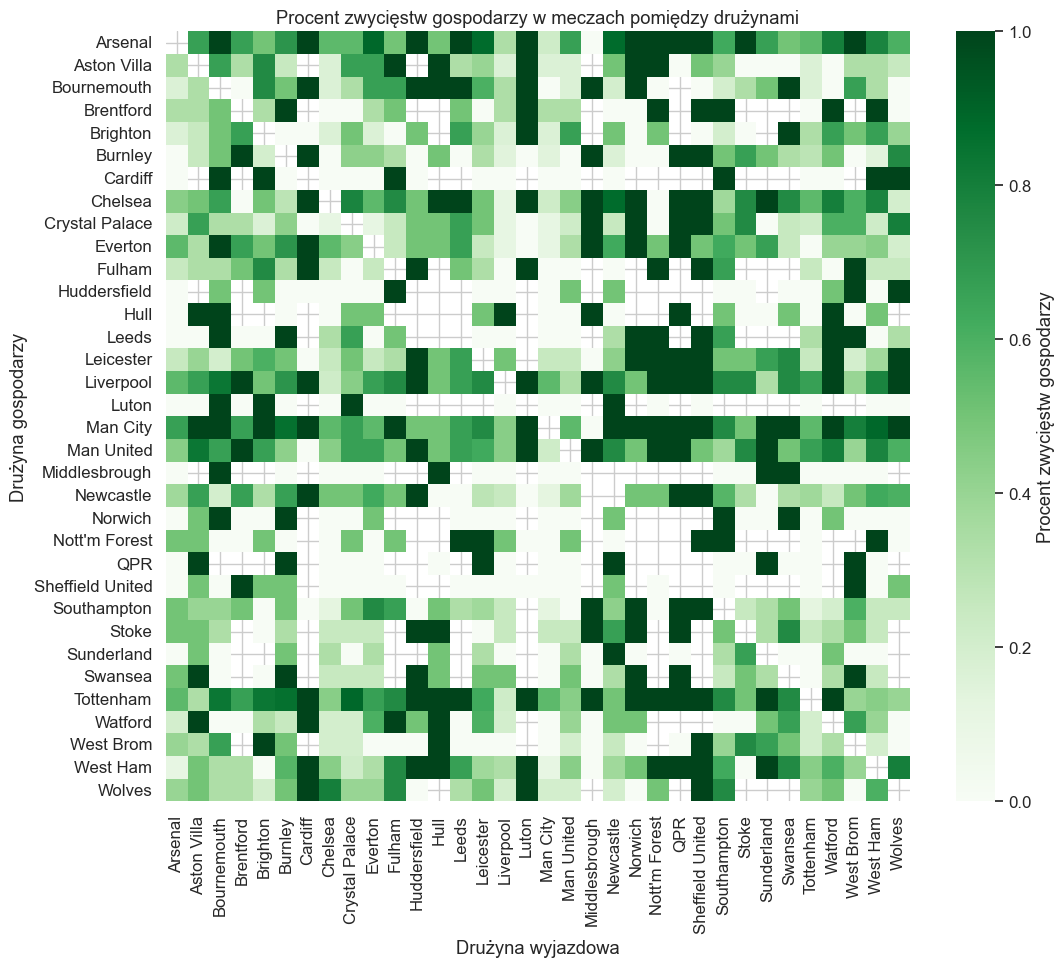

'\nfor season, data in df.groupby(\'Season\'):\n    pivot = pd.crosstab(data[\'HomeTeam\'], data[\'AwayTeam\'], values=(data[\'FTR\']==\'H\').astype(int), aggfunc=\'mean\')\n    plt.figure(figsize=(12,10))\n    sns.heatmap(pivot, cmap=\'Greens\', cbar_kws={\'label\': \'Procent zwycięstw gospodarzy\'})\n    plt.title(f"Procent zwycięstw gospodarzy – sezon {season}")\n    plt.show()\n'

In [391]:
pivot = pd.crosstab(df['HomeTeam'], df['AwayTeam'], values=(df['FTR']=='H').astype(int), aggfunc='mean')

plt.figure(figsize=(12,10))
sns.heatmap(pivot, cmap='Greens', cbar_kws={'label': 'Procent zwycięstw gospodarzy'})
plt.title("Procent zwycięstw gospodarzy w meczach pomiędzy drużynami")
plt.xlabel("Drużyna wyjazdowa")
plt.ylabel("Drużyna gospodarzy")
save_plot("home_win_matrix.png")
plt.show()

'''
for season, data in df.groupby('Season'):
    pivot = pd.crosstab(data['HomeTeam'], data['AwayTeam'], values=(data['FTR']=='H').astype(int), aggfunc='mean')
    plt.figure(figsize=(12,10))
    sns.heatmap(pivot, cmap='Greens', cbar_kws={'label': 'Procent zwycięstw gospodarzy'})
    plt.title(f"Procent zwycięstw gospodarzy – sezon {season}")
    plt.show()
'''

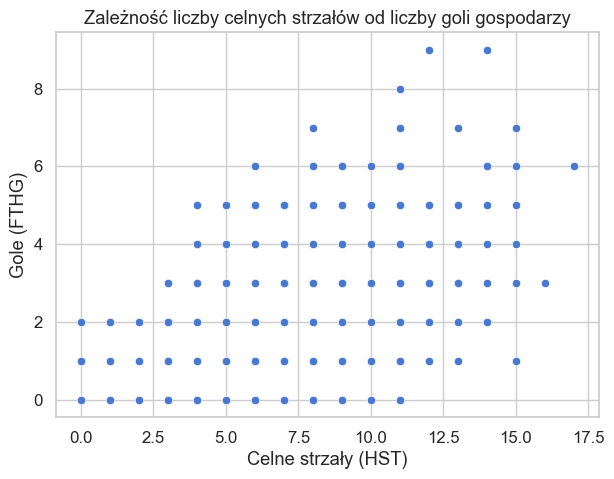

In [392]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='HST', y='FTHG', data=df)
plt.title("Zależność liczby celnych strzałów od liczby goli gospodarzy")
plt.xlabel("Celne strzały (HST)")
plt.ylabel("Gole (FTHG)")
save_plot("shots_on_target_vs_goals.png")
plt.show()


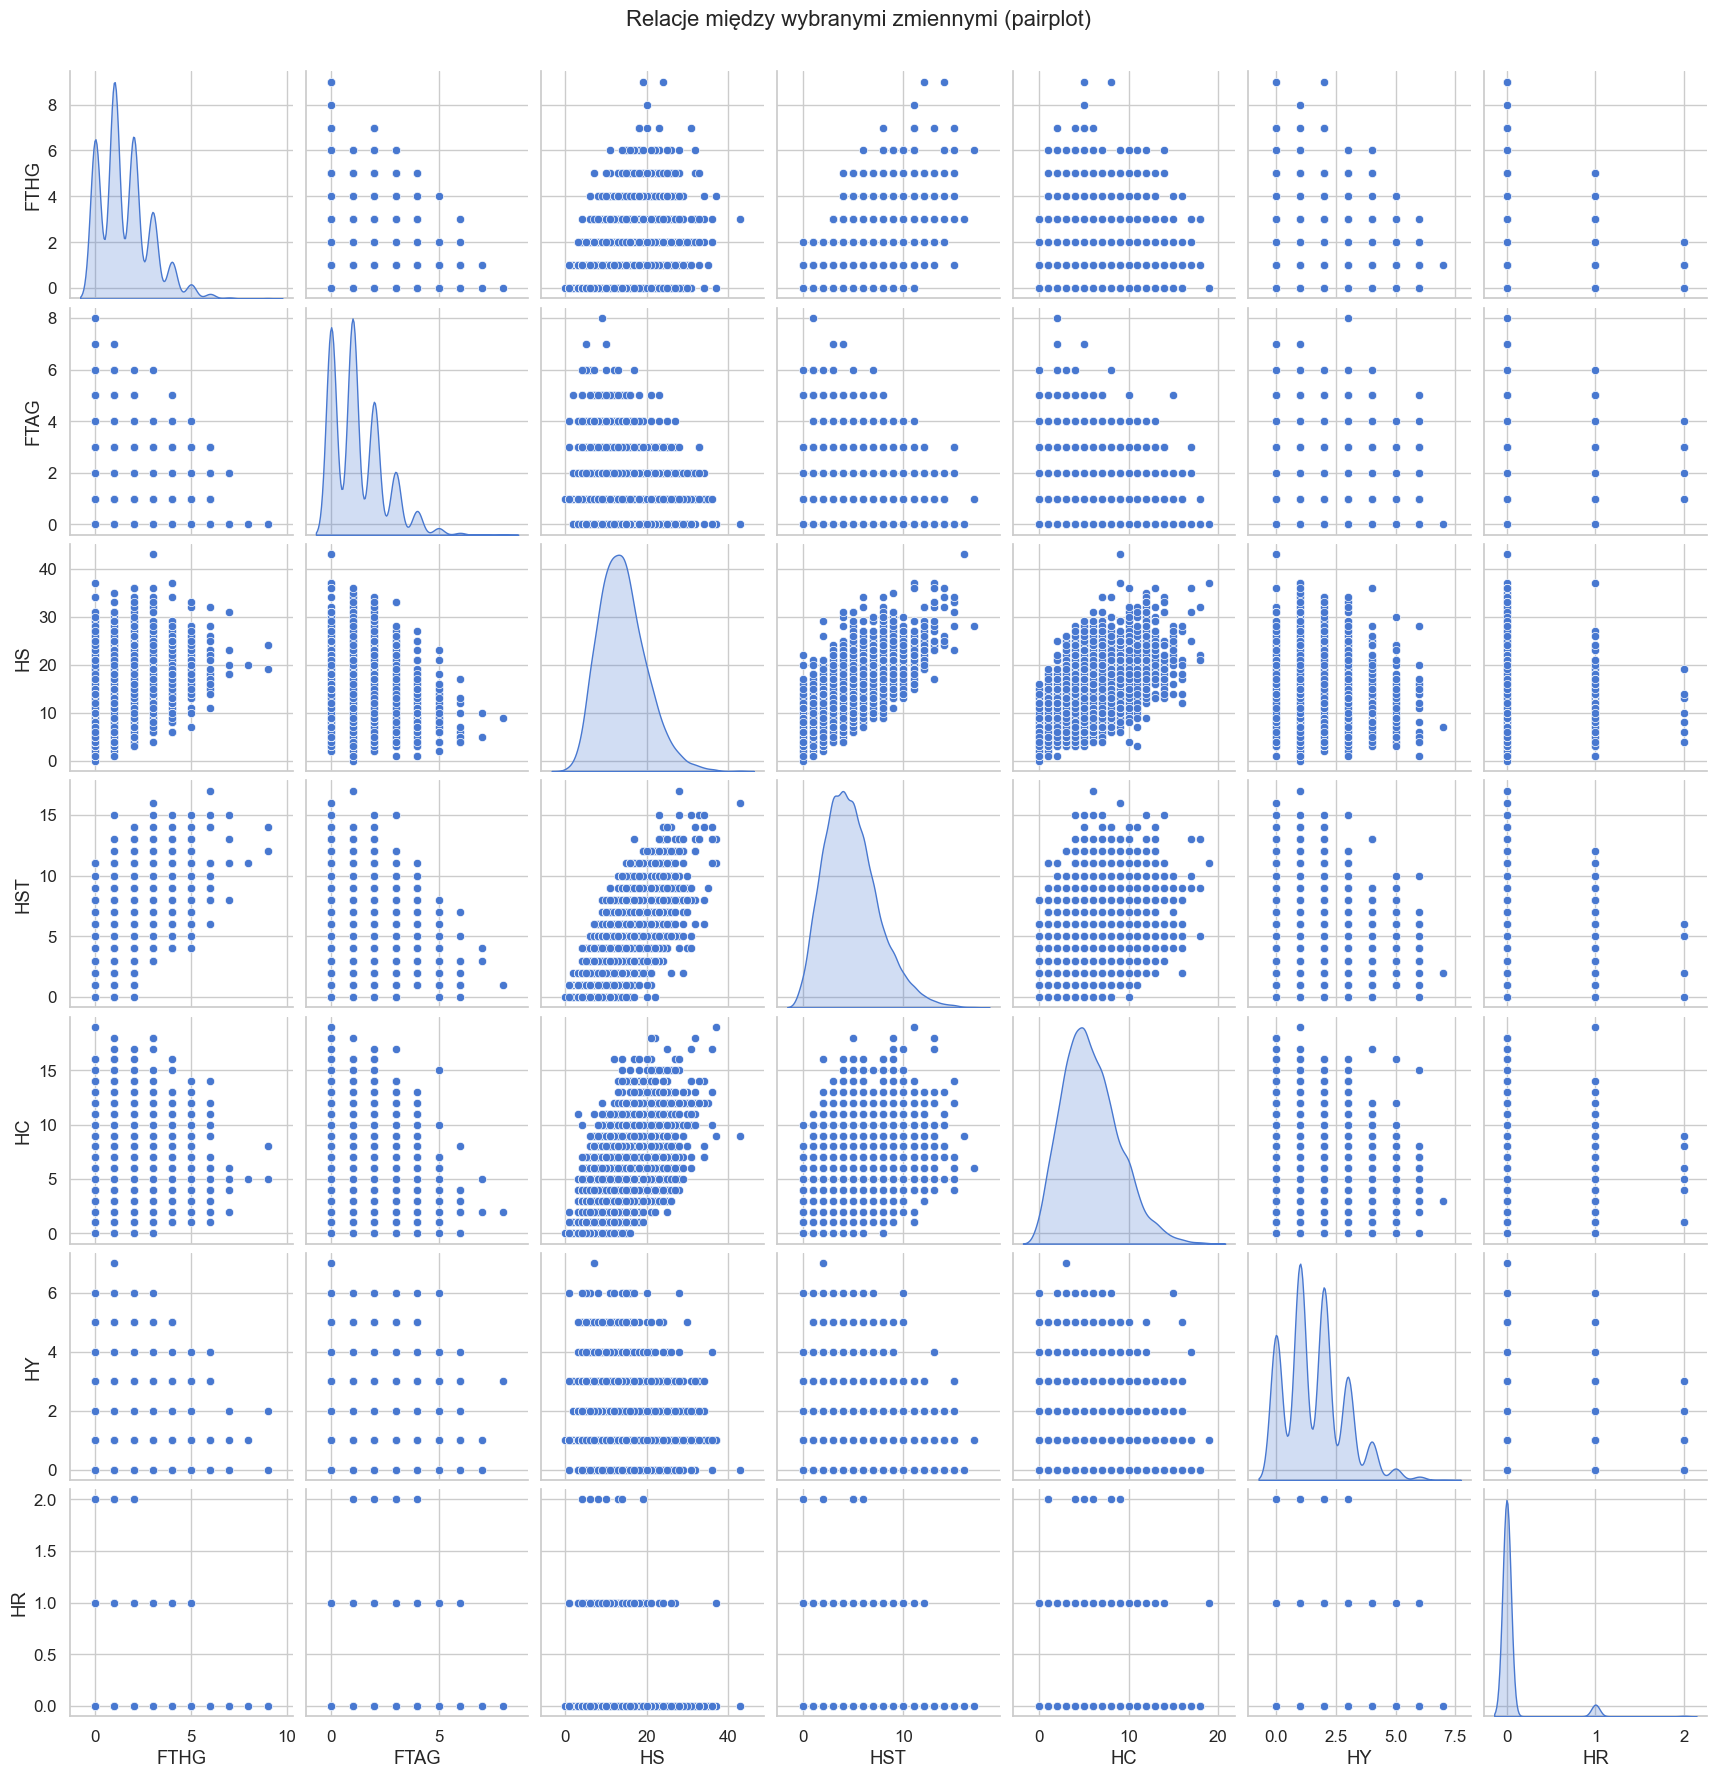

In [393]:
sns.pairplot(df[['FTHG', 'FTAG', 'HS', 'HST', 'HC', 'HY', 'HR']], diag_kind='kde')
plt.suptitle("Relacje między wybranymi zmiennymi (pairplot)", y=1.02)
save_plot("pairplot.png")
plt.show()


In [394]:
print(df.columns)

Index(['Div', 'Date', 'Season', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR',
       'AR', 'B365H', 'B365D', 'B365A', 'PSH', 'PSD', 'PSA', 'BbMxH', 'BbMxD',
       'BbMxA', 'BbAvH', 'BbAvD', 'BbAvA', 'Bb1X2', 'TotalGoals', 'Month'],
      dtype='object')


# Wnioski:


Celem tej sekcji jest zobrazowanie rozkładów i zależności pomiędzy kluczowymi zmiennymi,
takimi jak liczba strzałów, liczba goli, karty i kursy bukmacherskie.
Wizualizacje pomagają intuicyjnie zrozumieć zachowanie danych przed etapem modelowania.


### Wnioski z analizy

- Gospodarze oddają więcej strzałów i celnych strzałów w meczach, które wygrywają.
- Goście oddają więcej strzałów, gdy wygrywają, ale często mają mniej celnych trafień przy porażkach.
- Rzuty rożne nie mają wyraźnej zależności z wynikiem.
- Czerwone kartki częściej pojawiają się w meczach przegranych przez daną drużynę.
